# Homework 9

In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage


## Data Selection and Preparation

In [2]:
# Load the CSV file for the training dataset
data = pd.read_csv('world-data-2023.csv')
df = pd.DataFrame(data)

df.columns

Index(['Country', 'Density\n(P/Km2)', 'Abbreviation', 'Agricultural Land( %)',
       'Land Area(Km2)', 'Armed Forces size', 'Birth Rate', 'Calling Code',
       'Capital/Major City', 'Co2-Emissions', 'CPI', 'CPI Change (%)',
       'Currency-Code', 'Fertility Rate', 'Forested Area (%)',
       'Gasoline Price', 'GDP', 'Gross primary education enrollment (%)',
       'Gross tertiary education enrollment (%)', 'Infant mortality',
       'Largest city', 'Life expectancy', 'Maternal mortality ratio',
       'Minimum wage', 'Official language', 'Out of pocket health expenditure',
       'Physicians per thousand', 'Population',
       'Population: Labor force participation (%)', 'Tax revenue (%)',
       'Total tax rate', 'Unemployment rate', 'Urban_population', 'Latitude',
       'Longitude'],
      dtype='object')

In [3]:
# the list of columns i selected
child_df= df[['GDP','Gross primary education enrollment (%)', 'Infant mortality', 'Maternal mortality ratio','Out of pocket health expenditure','Physicians per thousand']]

In [4]:
child_df

,GDP,Gross primary education enrollment (%),Infant mortality,Maternal mortality ratio,Out of pocket health expenditure,Physicians per thousand
0,"$19,101,353,833",104.00%,47.9,638.0,78.40%,0.28
1,"$15,278,077,447",107.00%,7.8,15.0,56.90%,1.20
2,"$169,988,236,398",109.90%,20.1,112.0,28.10%,1.72
3,"$3,154,057,987",106.40%,2.7,NaN,36.40%,3.33
4,"$94,635,415,870",113.50%,51.6,241.0,33.40%,0.21
...,...,...,...,...,...,...
190,"$482,359,318,768",97.20%,21.4,125.0,45.80%,1.92
191,"$261,921,244,843",110.60%,16.5,43.0,43.50%,0.82
192,"$26,914,402,224",93.60%,42.9,164.0,81.00%,0.31
193,"$23,064,722,446",98.70%,40.4,213.0,27.50%,1.19


### Data cleaning

In [5]:
# Before interpolation
print("NAs before:",child_df.isna().sum().sum())

# Interpolate
child_df.interpolate(inplace=True)

# Check results
print("NAs after:", child_df.isna().sum().sum())

# Drop the remaining missing values
child_df = child_df.dropna() 
child_df.isna().sum().sum() 


NAs before: 43
NAs after: 16


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9420/2812192955.py:5: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  child_df.interpolate(inplace=True)
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9420/2812192955.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df.interpolate(inplace=True)


np.int64(0)

In [13]:
child_df.dtypes

GDP                                       float64
Gross primary education enrollment (%)    float64
Infant mortality                          float64
Maternal mortality ratio                  float64
Out of pocket health expenditure          float64
Physicians per thousand                   float64
dtype: object

In [12]:
# convert values to float
child_df.dtypes

# Remove '$'
child_df['GDP'] = child_df['GDP'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

# Remove '%' and convert to decimals
child_df['Gross primary education enrollment (%)'] = child_df['Gross primary education enrollment (%)'].astype(str).str.replace('%', '').astype(float) / 100
child_df['Out of pocket health expenditure'] = child_df['Out of pocket health expenditure'].astype(str).str.replace('%', '').astype(float) / 100


/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9420/588062723.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df['GDP'] = child_df['GDP'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)
/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9420/588062723.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df['Gross primary education enrollment (%)'] = child_df['Gross primary education enrollment (%)'].astype(str).str.replace('%', '').astype(float) / 100
/

### Data Preparation

In [15]:
# Standardize the features (important for clustering)
scaler = StandardScaler()
child_df_scaled = scaler.fit_transform(child_df)

child_df_scaled

array([[-0.21680263,  0.09810659,  1.38259494,  2.1182095 ,  2.37466153,
        -0.95179326],
       [-0.21852757,  0.35069445, -0.70643062, -0.64040981,  1.25248829,
        -0.36940884],
       [-0.14872729,  0.59486272, -0.06565719, -0.21089766, -0.2507019 ,
        -0.04023503],
       ...,
       [-0.21327763, -0.77753133,  1.12211794,  0.01935628,  2.5103662 ,
        -0.93280247],
       [-0.21501449, -0.34813197,  0.99187944,  0.23632634, -0.28201836,
        -0.3757391 ],
       [-0.21574717,  0.59486272,  0.65325933,  1.32117664, -0.37074834,
        -0.99610512]], shape=(184, 6))

/var/folders/34/91r13ymj4sv1jwnd5dkv2hc00000gp/T/ipykernel_9420/3885136886.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  child_df['cluster'] = clustering.fit_predict(child_df_scaled)


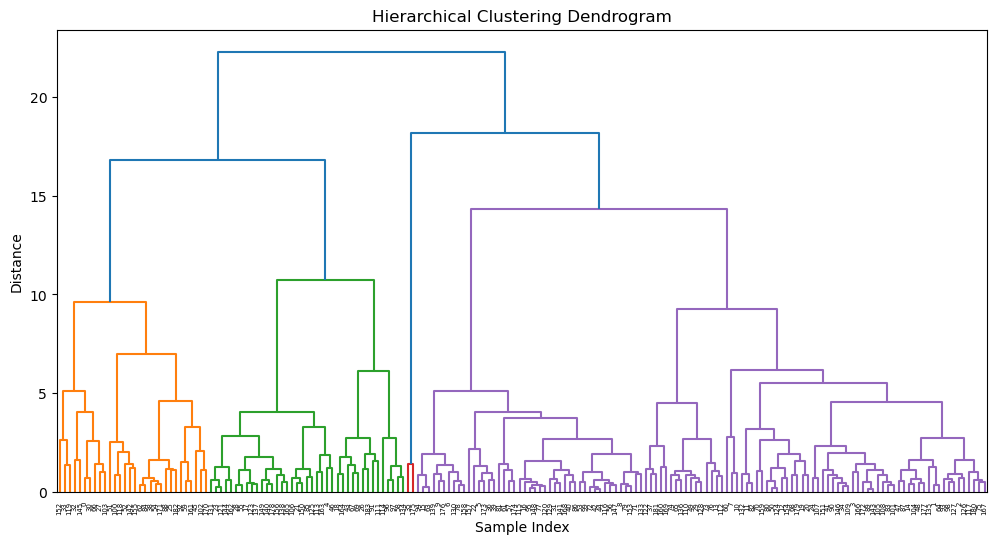

cluster
0    113
1     39
3     30
2      2
Name: count, dtype: int64
                  GDP  Gross primary education enrollment (%)  \
cluster                                                         
0        4.240826e+11                                0.010211   
1        3.949925e+10                                0.011401   
2        2.066885e+13                                0.010100   
3        3.779429e+10                                0.009117   

         Infant mortality  Maternal mortality ratio  \
cluster                                               
0               11.305310                 48.800885   
1               30.369231                203.491453   
2                6.500000                 24.000000   
3               48.513333                529.100000   

         Out of pocket health expenditure  Physicians per thousand  
cluster                                                             
0                                0.354973                 2.585929  
1

In [18]:
# 4. Perform hierarchical clustering
clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
child_df['cluster'] = clustering.fit_predict(child_df_scaled)

# 5. Create dendrogram to visualize
plt.figure(figsize=(12, 6))
Z = linkage(child_df_scaled, method='ward')
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

# 6. View cluster assignments
print(child_df['cluster'].value_counts())
print(child_df.groupby('cluster').mean())